# Fundamentos de *Deep Learning I*. 
> Héctor J. Hortúa, PhD. Instituto de Neurociencias
## Tensores y diferenciación automática con TensorFlow

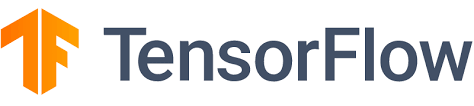



### Objetivos:

1. Explicar qué es un tensor y qué significan su **rango**, **forma** (*shape*), **eje** y **tipo** (*dtype*).
2. Diferenciar la ejecución **eager** de la ejecución en **grafo** (`@tf.function`) y saber cuándo importa cada una.
3. Crear y manipular tensores: indexado, *reshape*, operaciones elemento a elemento y matriciales, *broadcasting*.
4. Distinguir entre **tensores constantes** y **variables** (estado entrenable).
5. Calcular **derivadas automáticamente** con `tf.GradientTape`, base del entrenamiento de cualquier red.


## Popularidad y ecosistema

TensorFlow, desarrollado por Google y liberado en 2015, es uno de los dos frameworks dominantes de *Deep Learning* (el otro es PyTorch, que veremos en el notebook paralelo). Su gran fortaleza es el **ecosistema de despliegue**: TensorFlow Lite (móviles), TensorFlow.js (navegador), TFX (*pipelines* de producción) y TPUs.

Desde la versión 2.0, TensorFlow adoptó la **ejecución eager** por defecto y a **Keras** como su API de alto nivel, acercándose mucho a la ergonomía de PyTorch. En las encuestas anuales a desarrolladores (por ejemplo, Stack Overflow), TensorFlow y PyTorch aparecen consistentemente como los frameworks de aprendizaje profundo más usados y deseados.
>https://www.tensorflow.org/



## **Artitectura TensorFlow**
![image](https://codingclubuc3m.rbind.io/post/2018-07-03_files/pic0.png)

## Preparación del entorno

In [1]:
import tensorflow as tf 
import numpy as np       
import matplotlib.pyplot as plt
import timeit
from datetime import datetime

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## Modelo de ejecución: *Eager* vs *Graph*

TensorFlow puede ejecutar las operaciones de dos maneras. Entender la diferencia te evitará muchas sorpresas.

| | **Eager** (por defecto en TF2) | **Graph** (`@tf.function`) |
|---|---|---|
| **Cómo corre** | Operación por operación, como Python normal | Construye un **grafo** y lo optimiza antes de correr |
| **Depuración** | Fácil: puedes usar `print`, *breakpoints*, inspeccionar valores | Difícil: el código Python solo corre en el *trazado* |
| **Velocidad** | Más lenta (sin optimizaciones globales) | Más rápida (fusiona operaciones, paraleliza) |
| **Flujo de control** | Python nativo (`if`, `for`) | Se compila a operaciones del grafo |
| **Uso típico** | Prototipado, experimentación, aprendizaje | Producción, bucles de entrenamiento intensivos |

La regla práctica: **prototipa en eager, acelera con `@tf.function`** cuando el código ya funciona.

In [2]:
# Una función corriente de Python opera de forma "eager":
# cada línea se ejecuta inmediatamente.
def polinomio(x):
    return 2 * x**2 + 3 * x + 5

x = tf.constant([1.0, 2.0, 3.0, 4.0, 5.0])
print("Resultado eager:", polinomio(x).numpy())

Resultado eager: [10. 19. 32. 49. 70.]


Al **decorar** una función con `@tf.function`, TensorFlow la *traza* una vez y construye un grafo reutilizable. La primera llamada es más lenta (traza + compila); las siguientes son más rápidas.

In [3]:
@tf.function
def polinomio_grafo(x):
    return 2 * x**2 + 3 * x + 5

In [4]:
# Comparación de tiempos (10.000 llamadas)
print("Eager:", timeit.timeit(lambda: polinomio(x), number=10000))

Eager: 2.4304472000076203


In [5]:
print("Grafo:", timeit.timeit(lambda: polinomio_grafo(x), number=10000))

Grafo: 2.7928157999995165


> Cambiando `number>10000` se observa cómo la ventaja del grafo crece con el número de llamadas. En un bucle de entrenamiento con millones de pasos, esa diferencia es enorme.

## Tensores y rangos

Un **tensor** es un arreglo n-dimensional de datos de un mismo tipo. El **rango** es el número de ejes (dimensiones):

| Rango | Nombre | Ejemplo |
|---|---|---|
| 0 | Escalar | un número: `4` |
| 1 | Vector | `[2, 3, 4]` |
| 2 | Matriz | tabla filas × columnas |
| 3+ | Tensor | imágenes (alto × ancho × canales), *batches*, etc. |

En *Deep Learning* trabajarás casi siempre con tensores de rango 3 o 4 (por ejemplo, un lote de imágenes es `[batch, alto, ancho, canales]`).

![image](https://static.packt-cdn.com/products/9781787125933/graphics/B07030_14_01.jpg)

In [6]:
escalar = tf.constant(4, dtype=tf.int32)          # rango 0
vector  = tf.constant([2.0, 3.0, 4.0])             # rango 1
matriz  = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # rango 2

print("escalar:", escalar)
print("vector :", vector)
print("matriz :\n", matriz)

escalar: tf.Tensor(4, shape=(), dtype=int32)
vector : tf.Tensor([2. 3. 4.], shape=(3,), dtype=float32)
matriz :
 tf.Tensor(
[[1. 2.]
 [3. 4.]
 [5. 6.]], shape=(3, 2), dtype=float32)


In [8]:
# Tensor de rango 3: 3 "capas" de matrices 2x5
rank_3 = tf.constant([
    [[0, 1, 2, 3, 4],    [5, 6, 7, 8, 9]],
    [[10,11,12,13,14],   [15,16,17,18,19]],
    [[20,21,22,23,24],   [25,26,27,28,29]],
])
print("shape:", rank_3.shape, "| rango:", tf.rank(rank_3).numpy())
print(rank_3)

shape: (3, 2, 5) | rango: 3
tf.Tensor(
[[[ 0  1  2  3  4]
  [ 5  6  7  8  9]]

 [[10 11 12 13 14]
  [15 16 17 18 19]]

 [[20 21 22 23 24]
  [25 26 27 28 29]]], shape=(3, 2, 5), dtype=int32)


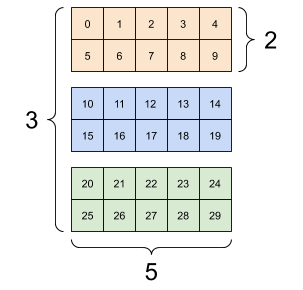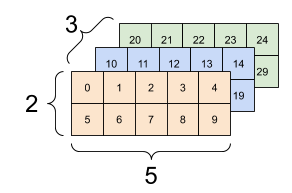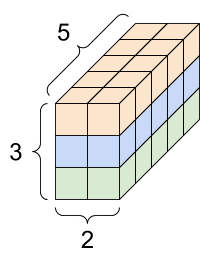

### Indexado y *slicing*

El indexado sigue la convención de NumPy: `tensor[eje0, eje1, eje2]`. Los dos puntos `:` seleccionan **todo** ese eje.

In [9]:
print("Todos los elementos de la columna 4 (último índice):")
print(rank_3[:, :, 4].numpy())

print("\nLa segunda 'capa' completa (índice 1):")
print(rank_3[1, :, :].numpy())

Todos los elementos de la columna 4 (último índice):
[[ 4  9]
 [14 19]
 [24 29]]

La segunda 'capa' completa (índice 1):
[[10 11 12 13 14]
 [15 16 17 18 19]]


### Conversión a NumPy

Todo tensor de TF puede convertirse a un arreglo de NumPy con `.numpy()`. Esto es clave para graficar, depurar o integrar con librerías del ecosistema científico de Python.

In [10]:
arr = rank_3.numpy()
print(type(arr), arr.shape)

<class 'numpy.ndarray'> (3, 2, 5)


## Operaciones sobre tensores

TensorFlow define operaciones **elemento a elemento** (suma, multiplicación) y operaciones **matriciales** (producto de matrices). Puedes usar las funciones (`tf.add`, `tf.matmul`) o los operadores de Python (`+`, `*`, `@`), que son equivalentes.

In [9]:
a = tf.constant([[1, 2], [3, 4]])
b = tf.ones([2, 2], dtype=tf.int32)

print("Suma (elemento a elemento):\n", tf.add(a, b).numpy())
print("Producto elemento a elemento:\n", tf.multiply(a, b).numpy())
print("Producto MATRICIAL:\n", tf.matmul(a, b).numpy())

# Equivalente con operadores de Python:
print("\nCon operadores  a+b, a*b, a@b:")
print((a + b).numpy(), "\n", (a * b).numpy(), "\n", (a @ b).numpy())

Suma (elemento a elemento):
 [[2 3]
 [4 5]]
Producto elemento a elemento:
 [[1 2]
 [3 4]]
Producto MATRICIAL:
 [[3 3]
 [7 7]]

Con operadores  a+b, a*b, a@b:
[[2 3]
 [4 5]] 
 [[1 2]
 [3 4]] 
 [[3 3]
 [7 7]]


### Reducciones

Las **reducciones** colapsan un tensor a lo largo de uno o varios ejes: máximo, media, índice del máximo, etc. Son omnipresentes en el cálculo de *loss* y métricas.

In [11]:
c = tf.constant([[4.0, 5.0], [10.0, 1.0]])
print("máximo   :", tf.reduce_max(c).numpy())
print("media    :", tf.reduce_mean(c).numpy())
print("argmax   :", tf.argmax(c).numpy(), "(índice del máximo por columna)")

máximo   : 10.0
media    : 5.0
argmax   : [1 0] (índice del máximo por columna)


Un ejemplo visual: la función de activación **ReLU** aplicada a ruido aleatorio. ReLU es simplemente `max(0, x)` y es la activación más usada en redes profundas (la veremos a fondo en el Módulo 3).

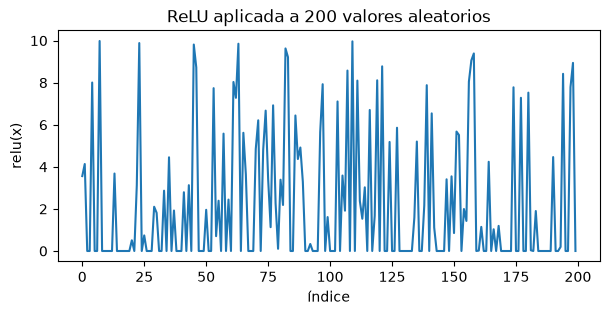

In [12]:
d = tf.random.uniform(shape=[200], minval=-10.0, maxval=10.0)
plt.figure(figsize=(7, 3))
plt.plot(tf.nn.relu(d).numpy())
plt.title("ReLU aplicada a 200 valores aleatorios")
plt.xlabel("índice"); plt.ylabel("relu(x)")
plt.show()

## Propiedades de un tensor

Cuatro atributos que consultarás constantemente para depurar errores de forma (*shape errors*), la causa #1 de frustración al empezar:

- **`shape`** — longitud de cada eje.
- **`rank` / `ndim`** — número de ejes.
- **`dtype`** — tipo de dato de los elementos.
- **`size`** — número total de elementos.

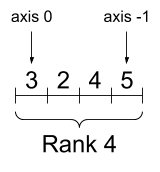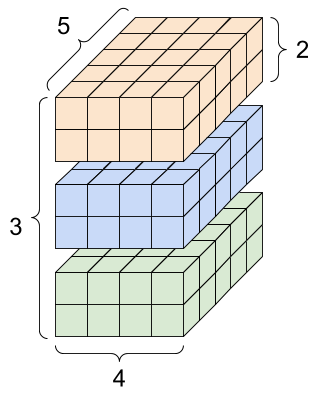

In [13]:
t = tf.zeros([3, 2, 4, 5])
print("shape         :", t.shape)
print("rango (ndim)  :", t.ndim)
print("dtype         :", t.dtype)
print("size total    :", tf.size(t).numpy(), "(= 3*2*4*5)")
print("eje 0         :", t.shape[0], "| último eje:", t.shape[-1])

shape         : (3, 2, 4, 5)
rango (ndim)  : 4
dtype         : <dtype: 'float32'>
size total    : 120 (= 3*2*4*5)
eje 0         : 3 | último eje: 5


## *Reshape*: reorganizar sin copiar datos

`tf.reshape` cambia la **forma** de un tensor conservando el **orden** de sus elementos. El total de elementos debe coincidir. El valor especial `-1` significa *"calcula tú esta dimensión"*.

In [14]:
print("Aplanado a 1D:", tf.reshape(rank_3, [-1]).numpy())
print("\nDe [3,2,5] a [6,5]:\n", tf.reshape(rank_3, [6, 5]).numpy())
print("\nUsando -1  ->  [3,-1] equivale a [3,10]:")
print(tf.reshape(rank_3, [3, -1]).shape)

Aplanado a 1D: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

De [3,2,5] a [6,5]:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]
 [25 26 27 28 29]]

Usando -1  ->  [3,-1] equivale a [3,10]:
(3, 10)


## *Broadcasting*

El *broadcasting* permite operar tensores de formas distintas **sin copiar datos explícitamente**: TensorFlow incrementa virtualmente la dimensión de tamaño 1 para que coincidan. Es la misma regla de NumPy y ahorra memoria y código.

In [16]:
x = tf.constant([1, 2, 3])
print("Vector * escalar:", (x * 3).numpy())

a = tf.constant([[1.0, 2.0], [3.0, 4.0]])   # (2,2)
b = tf.constant([[1.0], [2.0]])             # (2,1) ->  (2,2)
print("Matriz (2,2) + columna (2,1):\n", (a + b).numpy())

Vector * escalar: [3 6 9]
Matriz (2,2) + columna (2,1):
 [[2. 3.]
 [5. 6.]]


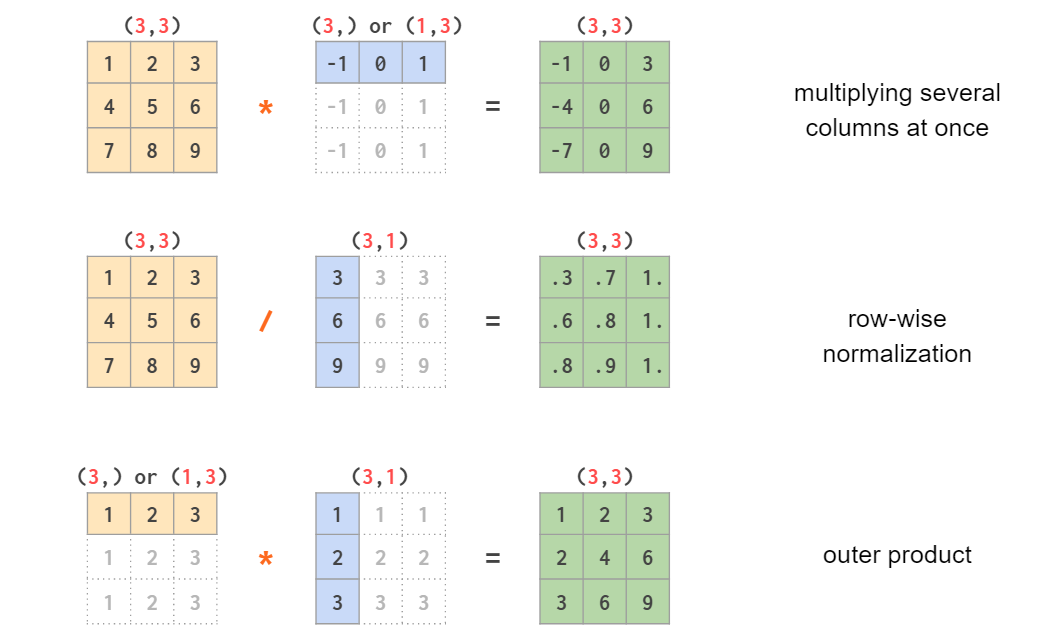

## Tipos especiales de tensores

No todos los datos son rectangulares. TensorFlow ofrece:

- **`RaggedTensor`** — filas de longitud variable (frecuente en texto: frases de distinto largo).
- **Tensores de *strings*** — texto como dato de primera clase.
- **`SparseTensor`** — casi todo ceros; guarda solo los valores no nulos (eficiente en memoria).

In [17]:
# Ragged: cada fila tiene distinta longitud
ragged = tf.ragged.constant([[0, 1, 2, 3], [4, 5], [6, 7, 8], [9]])
print(ragged)
print("shape:", ragged.shape, "\n")

# Strings
frases = tf.constant(["Bienvenidos", "al curso de", "TensorFlow 2"])
print(tf.strings.split(frases, sep=" "))

<tf.RaggedTensor [[0, 1, 2, 3], [4, 5], [6, 7, 8], [9]]>
shape: (4, None) 

<tf.RaggedTensor [[b'Bienvenidos'], [b'al', b'curso', b'de'], [b'TensorFlow', b'2']]>


In [18]:
# Sparse: se definen solo los índices con valor
sparse = tf.sparse.SparseTensor(indices=[[0, 0], [1, 2]],
                                values=[1, 2],
                                dense_shape=[3, 4])
print("Denso equivalente:\n", tf.sparse.to_dense(sparse).numpy())

Denso equivalente:
 [[1 0 0 0]
 [0 0 2 0]
 [0 0 0 0]]


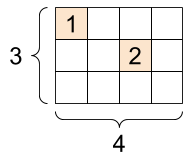

`tf.where` es el equivalente de TensorFlow al if vectorizado de NumPy. 

In [19]:
x = tf.constant([1, -2, 3, -4, 5])
idx = tf.where(x > 0)
print(idx)
# [[0], [2], [4]]  → posiciones donde x > 0

tf.Tensor(
[[0]
 [2]
 [4]], shape=(3, 1), dtype=int64)


### ReLU manual

In [20]:
x = tf.constant([1, -2, 3, -4, 5])
y = tf.where(x > 0, x, 0)
print(y)
# [1, 0, 3, 0, 5]  → reemplaza negativos por 0 

tf.Tensor([1 0 3 0 5], shape=(5,), dtype=int32)


In [21]:
x = tf.constant([[1, 2, 3],
                 [4, 5, 6]])
cond = x > 3
resultado = tf.where(cond, x, -x)
print(resultado)

tf.Tensor(
[[-1 -2 -3]
 [ 4  5  6]], shape=(2, 3), dtype=int32)


## Variables: el estado que la red aprende

Hasta aquí todo fueron **constantes** (`tf.constant`), inmutables. Pero una red neuronal necesita **parámetros que cambian** durante el entrenamiento: los **pesos**. Para eso existe `tf.Variable`.

La diferencia es fundamental:

- `tf.constant` → valor fijo.
- `tf.Variable` → valor **mutable** (con `.assign`) y, por defecto, **rastreado por el motor de gradientes** (`trainable=True`).

**Los pesos de toda red neuronal son `tf.Variable`.**

In [22]:
v = tf.Variable([[1.0, 2.0], [3.0, 4.0]])
print("Valor inicial:\n", v.numpy())

v.assign([[11.0, 11.0], [4.0, 7.0]])          # reemplaza el contenido
print("Tras assign:\n", v.numpy())

v.assign_add([[1.0, 1.0], [1.0, 1.0]])        # suma en el sitio
print("Tras assign_add:\n", v.numpy())

Valor inicial:
 [[1. 2.]
 [3. 4.]]
Tras assign:
 [[11. 11.]
 [ 4.  7.]]
Tras assign_add:
 [[12. 12.]
 [ 5.  8.]]


## `tf.einsum`: notación de Einstein

`einsum` expresa productos y contracciones de tensores con una notación compacta. Es opcional pero elegante y aparece en implementaciones de *transformers* y atención (Módulo 7).

In [23]:
a = tf.constant([[1, 2], [3, 4]])
b = tf.ones([2, 2], dtype=tf.int32)

print("Producto matricial 'ij,jk->ik':\n", tf.einsum('ij,jk->ik', a, b).numpy())
print("Transpuesta 'ij->ji':\n", tf.einsum('ij->ji', a).numpy())

# Producto matricial por lotes (batch de 7)
s = tf.ones([7, 5, 3]); t = tf.ones([7, 3, 2])
print("Batch matmul 'bij,bjk->bik' shape:", tf.einsum('bij,bjk->bik', s, t).shape)

Producto matricial 'ij,jk->ik':
 [[3 3]
 [7 7]]
Transpuesta 'ij->ji':
 [[1 3]
 [2 4]]
Batch matmul 'bij,bjk->bik' shape: (7, 5, 2)


## Interoperabilidad con NumPy

TensorFlow y NumPy conviven sin fricción: las operaciones de TF aceptan arreglos de NumPy y viceversa. Esto te permite reutilizar todo el ecosistema científico de Python.

In [24]:
m = tf.reshape(tf.range(9), [3, 3])
print("tensor + numpy:\n", (m + m.numpy()).numpy())

desde_numpy = tf.convert_to_tensor(np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32))
print("Convertido desde NumPy:\n", desde_numpy.numpy())

tensor + numpy:
 [[ 0  2  4]
 [ 6  8 10]
 [12 14 16]]
Convertido desde NumPy:
 [[1. 2.]
 [3. 4.]]


## Diferenciación automática 

Entrenar una red consiste en:

1. Calcular una **función de pérdida** (*loss*).
2. Calcular el **gradiente** de esa pérdida respecto a cada peso (¿en qué dirección hay que mover cada peso para reducir el error?).
3. Actualizar los pesos en dirección opuesta al gradiente (*descenso de gradiente*).

TensorFlow **registra** las operaciones que realizamos y luego recorre ese registro hacia atrás aplicando la regla de la cadena. En TF, ese registro es `tf.GradientTape` (una "cinta" que graba).

> Esto **no** es derivación simbólica (como Wolfram) ni numérica (aproximar con diferencias finitas). Es *autodiff*: exacta y eficiente.

### Ejemplo mínimo: derivada de $y = x^2$

Sabemos que $\dfrac{dy}{dx} = 2x$. En $x = 3$ debería dar $6$.

In [30]:
x = tf.Variable(3.0)

with tf.GradientTape() as tape:   
    y = x**2

dy_dx = tape.gradient(y, x)   
print("dy/dx en x=3:", dy_dx.numpy(), "(esperado: 6.0)")

dy/dx en x=3: 6.0 (esperado: 6.0)



Por defecto, `GradientTape` **solo rastrea `tf.Variable`** (los parámetros entrenables). Si necesitas derivar respecto de un `tf.constant`, debes pedírselo explícitamente con `tape.watch(...)`.

In [32]:
x_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(x_const)     
    y = x_const**2
print("dy/dx (constante observada):", tape.gradient(y, x_const).numpy())

dy/dx (constante observada): 6.0


In [33]:
trainable = tf.Variable(1.,name='x_trainable')
non_trainable = tf.Variable(2., trainable=False,name='x_No_trainable')
with tf.GradientTape(persistent=True) as tape:
  
  x1 = trainable * 2.
  x2 = non_trainable * 2.
tape.gradient(x1, trainable)              
tape.gradient(x2, non_trainable)        

In [35]:
[var.name for var in tape.watched_variables()]

['x_trainable:0']

Si queremos que `GradientTape` sea persistente

In [37]:
x = tf.Variable(3.0)

with tf.GradientTape(persistent=True) as tape:
    y = x**2
    z = x**3

dy_dx = tape.gradient(y, x)   
dz_dx = tape.gradient(z, x)   

print("dy/dx =", dy_dx.numpy()) 
print("dz/dx =", dz_dx.numpy())   

del tape 


dy/dx = 6.0
dz/dx = 27.0


### Gradiente respecto de varios parámetros

En una red real derivamos la pérdida respecto de **todos** los pesos a la vez. Aquí simulamos una capa lineal $y = xW + b$ con pérdida cuadrática media.

In [38]:
w = tf.Variable(tf.random.normal((3, 2)), name='w')
b = tf.Variable(tf.zeros(2), name='b')
x = tf.constant([[1.0, 2.0, 3.0]])

with tf.GradientTape() as tape:
    y = x @ w + b                # capa lineal
    loss = tf.reduce_mean(y**2)  # pérdida
[dl_dw, dl_db] = tape.gradient(loss, [w, b])
print("Gradiente respecto de w (shape", dl_dw.shape, "):\n", dl_dw.numpy())
print("Gradiente respecto de b:", dl_db.numpy())

Gradiente respecto de w (shape (3, 2) ):
 [[ -4.6444416  -2.7607226]
 [ -9.288883   -5.5214453]
 [-13.933325   -8.282167 ]]
Gradiente respecto de b: [-4.6444416 -2.7607226]


### Visualizar una derivada: la sigmoide y su pendiente

Podemos derivar respecto de un vector completo para dibujar una función **y** su derivada. Aquí la **sigmoide** $\sigma(x)=\frac{1}{1+e^{-x}}$, una activación clásica, junto a su derivada.

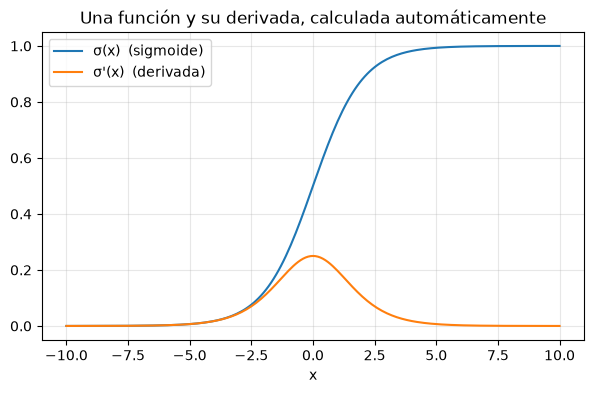

In [39]:
x = tf.linspace(-10.0, 10.0, 201)
with tf.GradientTape() as tape:
    tape.watch(x)
    y = tf.nn.sigmoid(x)
dy_dx = tape.gradient(y, x)

plt.figure(figsize=(7, 4))
plt.plot(x, y, label='σ(x)  (sigmoide)')
plt.plot(x, dy_dx, label="σ'(x)  (derivada)")
plt.legend(); plt.xlabel('x'); plt.grid(alpha=0.3)
plt.title("Una función y su derivada, calculada automáticamente")
plt.show()

### Derivadas de orden superior

Anidando gradientTape se obtienen segundas derivadas (y superiores). Para $y=x^3$: la primera derivada es $3x^2$ y la segunda $6x$.

In [40]:
x = tf.Variable(2.0)
with tf.GradientTape() as tape2:
    with tf.GradientTape() as tape1:
        y = x**3
    dy_dx = tape1.gradient(y, x)      # 3x^2 = 12
d2y_dx2 = tape2.gradient(dy_dx, x)   # 6x = 12
print("primera derivada :", dy_dx.numpy())
print("segunda derivada :", d2y_dx2.numpy())

primera derivada : 12.0
segunda derivada : 12.0


## Verificación de una solución analítica de una EDO con `tf.GradientTape()`

Usemos `tf.GradientTape()`  como **diferenciador automático** que evalúa el residuo de una EDO a partir de una función analítica candidata. Tomamos \(y(t)=cos(t)\) como posible solución de \(y''+y=0\), calculamos sus derivadas mediante tapes anidados o persistent.

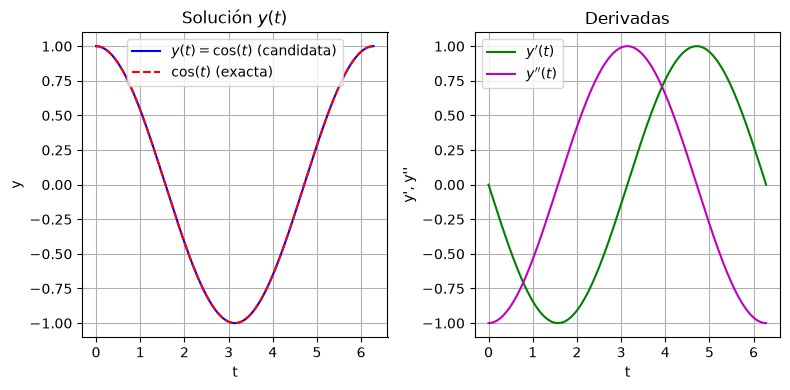

In [41]:
def y_analitica(t):
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    return tf.cos(t)
# Tape anidado
def calcular_derivadas(t):
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    with tf.GradientTape() as tape2:
        tape2.watch(t)
        with tf.GradientTape() as tape1:
            tape1.watch(t)
            y = y_analitica(t)
        dy_dt = tape1.gradient(y, t)
    d2y_dt2 = tape2.gradient(dy_dt, t)
    return y, dy_dt, d2y_dt2
#Persistent
def calcular_derivadas(t):
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        y = y_analitica(t)
        dy_dt = tape.gradient(y, t)        # dentro del with
        d2y_dt2 = tape.gradient(dy_dt, t)  # sigue rastreando dy_dt
    del tape  
    return y, dy_dt, d2y_dt2


t_vals = np.linspace(0.0, 2*np.pi, 200).reshape(-1, 1).astype(np.float32)

y, dy_dt, d2y_dt2 = calcular_derivadas(t_vals)
residuo = d2y_dt2 + y                 # y'' + y = 0
y_exacta = tf.cos(t_vals)
error = tf.abs(y - y_exacta)

t_np       = t_vals.flatten()
y_np       = y.numpy().flatten()
dy_np      = dy_dt.numpy().flatten()
d2y_np     = d2y_dt2.numpy().flatten()
yex_np     = y_exacta.numpy().flatten()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# (a) Solución y(t) vs exacta
axs[0].plot(t_np, y_np, 'b-', label=r'$y(t)=\cos(t)$ (candidata)')
axs[0].plot(t_np, yex_np, 'r--', label=r'$\cos(t)$ (exacta)')
axs[0].set_title('Solución $y(t)$')
axs[0].set_xlabel('t'); axs[0].set_ylabel('y')
axs[0].legend(); axs[0].grid(True)

# (b) Primera y segunda derivada
axs[1].plot(t_np, dy_np, 'g-', label=r"$y'(t)$")
axs[1].plot(t_np, d2y_np, 'm-', label=r"$y''(t)$")
axs[1].set_title('Derivadas')
axs[1].set_xlabel('t'); axs[1].set_ylabel("y', y''")
axs[1].legend(); axs[1].grid(True)

plt.tight_layout()
plt.show()


# MCMC: Metropolis-Hastings en TensorFlow

Finalmente implementemos un sampler **Metropolis-Hastings** desde cero usando solo TensorFlow para muestrear de una distribución Normal estándar $\mathcal{N}(0,1)$.

Algoritmo MCMC: propuesta, razón de aceptación y aceptación/rechazo.

1. Empezar en un estado inicial $x_0$.
2. Proponer un nuevo estado $x' \sim q(x' \mid x)$ (propuesta de caminata aleatoria simétrica: $x' = x + \epsilon$, con $\epsilon \sim \mathcal{N}(0, \sigma^2)$).
3. Calcular la razón de aceptación:
   $$
   \alpha = \min\left(1, \frac{p(x')\,q(x \mid x')}{p(x)\,q(x' \mid x)}\right)
   $$
   Como la propuesta es simétrica $q(x \mid x') = q(x' \mid x)$, se simplifica a $\alpha = \min(1, p(x')/p(x))$.
4. Aceptar con probabilidad $\alpha$: si $u \sim U(0,1)$ y $u < \alpha$, entonces $x_{t+1} = x'$; si no, $x_{t+1} = x_t$.

> **Nota numérica:** trabajamos en espacio logarítmico para evitar desbordamientos. La condición $u < \alpha$ se implementa como $\log u < \log\alpha$.


Tasa de aceptación: 0.849  (ideal ~0.23-0.45)
Media muestral:     0.0187 (esperado 0)
Desv. estándar:     0.9436 (esperado 1)


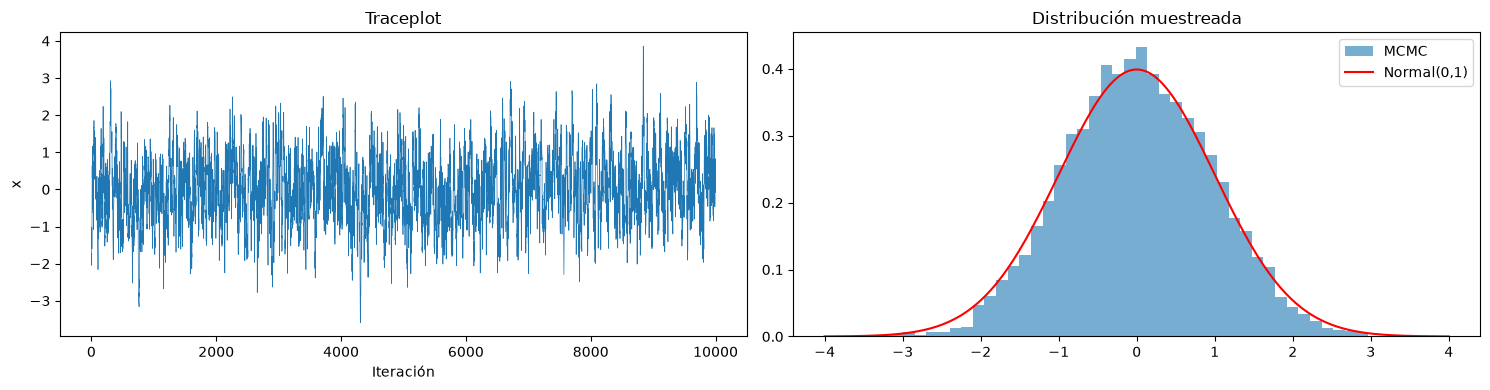

In [ ]:

# Log-densidad objetivo (Normal, sin normalizar)
def log_prob(x):
    return -0.5 * x ** 2

# Kernel Metropolis-Hastings (Random Walk)
@tf.function
def mh_step(x_current, sigma=0.5):
    # Propuesta simétrica: x' = x + N(0, sigma^2)
    x_prop = x_current +   tf.random.normal(shape=(),stddev=sigma,dtype=tf.float32)

    # Log-razón de aceptación
    log_alpha = log_prob(x_prop) - log_prob(x_current)
    # min(1, exp(log_alpha)) → comparamos log(u) < log_alpha
    log_u = tf.math.log(tf.random.uniform(shape=(), dtype=tf.float32))

    aceptar = log_u < log_alpha
    x_new = tf.where(aceptar, x_prop, x_current)
    return x_new, aceptar

#  Cadena MCMC
def sample_chain(n_samples=5000, burnin=1000, x0=5.0, sigma=0.5):
    x = tf.constant(x0, dtype=tf.float32)
    samples = []
    aceptados = 0

    for i in range(n_samples + burnin):
        x, acc = mh_step(x, sigma)
        if i >= burnin:
            samples.append(x.numpy())
            aceptados += int(acc.numpy())

    tasa_aceptacion = aceptados / n_samples
    return np.array(samples), tasa_aceptacion


samples, tasa = sample_chain(n_samples=10000, burnin=5000, x0=5.0, sigma=0.5)

print(f"Tasa de aceptación: {tasa:.3f}  (ideal ~0.23-0.45)")
print(f"Media muestral:     {samples.mean():.4f} (esperado 0)")
print(f"Desv. estándar:     {samples.std():.4f} (esperado 1)")


fig, axs = plt.subplots(1, 2, figsize=(15, 4))

# (a) Traceplot
axs[0].plot(samples, linewidth=0.5)
axs[0].set_title('Traceplot')
axs[0].set_xlabel('Iteración'); axs[0].set_ylabel('x')

# (b) Histograma vs densidad teórica
axs[1].hist(samples, bins=50, density=True, alpha=0.6, label='MCMC')
x_grid = np.linspace(-4, 4, 200)
axs[1].plot(x_grid, np.exp(-0.5 * x_grid**2) / np.sqrt(2*np.pi),
            'r-', label='Normal(0,1)')
axs[1].set_title('Distribución muestreada')
axs[1].legend()


plt.tight_layout()
plt.show()